# 1. Import and Hardware Setup

In [3]:
import torch
print(f"Unterstützte Architekturen: {torch.cuda.get_arch_list()}")
import torch.optim as optim
import torch.nn as nn

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import matplotlib.pyplot as plt

!pip install tqdm ipywidgets -q
from tqdm.auto import tqdm

Unterstützte Architekturen: ['sm_50', 'sm_60', 'sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90']


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

DATA_PATH = './Data'

cuda


# 2. Hyperparameter

In [5]:
IMG_SIZE = 224
IN_CHANNELS = 3
BATCH_SIZE = 128
NUM_CLASSES = 101

EPOCHS = 150
LR = 3e-3

SEED = 42

# 3. Data Preparation

In [6]:
stats = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(IMG_SIZE),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(*stats)
])

In [7]:
import os
import numpy as np
import random

def set_seed(seed: int=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        torch.use_deterministic_algorithms(False)
    except Exception:
        pass

set_seed(SEED)

In [8]:
# Download dummy data without transforms
dummy_data = datasets.Food101(root=DATA_PATH, split="train", download=True)

# Random split the dummy data and extract the indices
train_size = int(0.8 * len(dummy_data))
val_size = len(dummy_data) - train_size
split_generator = torch.Generator().manual_seed(SEED)
train_tmp_subset, val_tmp_subset = random_split(
    dummy_data, [train_size, val_size], generator=split_generator
)

train_indices = train_tmp_subset.indices
val_indices = val_tmp_subset.indices

# Create train and validation subset with correct transform
train_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=train_transform
)
val_dataset = datasets.Food101(
    root=DATA_PATH, split="train", download=False, transform=test_transform
)

train_subset = Subset(train_dataset, train_indices)
val_subset = Subset(val_dataset, val_indices)

# Download test dataset
test_dataset = datasets.Food101(
    root=DATA_PATH, split="test", download=True, transform=test_transform
)

100%|██████████| 5.00G/5.00G [02:37<00:00, 31.8MB/s] 


Extracting ./Data/food-101.tar.gz to ./Data


In [9]:
def seed_worker(worker_id):
    worker_seed = worker_id + SEED
    random.seed(worker_seed)
    np.random.seed(worker_seed)


train_generator = torch.Generator().manual_seed(SEED)
eval_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    persistent_workers=True,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=train_generator,
)
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    persistent_workers=False,
    pin_memory=False,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    persistent_workers=False,
    pin_memory=False,
    worker_init_fn=seed_worker,
    generator=eval_generator,
)

# 4. Network Architecture

![MobileNet](figures/MobileNetV1.png)

In [10]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, stride, alpha=1.0):
        super().__init__()
        in_channels = int(in_channels * alpha)
        out_channels = int(out_channels * alpha)
        
        # 1. Depthwise Convolution: filter each channel seperately
        self.depthwise = nn.Sequential(
            nn.Conv2d(in_channels, in_channels, kernel_size=3, stride=stride,
                      padding=1, groups=in_channels, bias=False),
            nn.BatchNorm2d(in_channels),
            nn.ReLU(inplace=True)
        )
        
        # 2. Pointwise Convolution: combines the Channels via 1x1 Conv
        self.pointwise = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=1,
                      padding=0, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x
    
class MobileNetV1(nn.Module):
    def __init__(self, in_channels, num_classes, alpha=1.0):
        super().__init__()
        
        # The first conv
        self.first_conv = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(int(32 * alpha)),
            nn.ReLU(inplace=True)
        )
        
        # Layers structure
        self.layers = nn.Sequential(
            DepthwiseSeparableConv(32, 64, 1, alpha),
            DepthwiseSeparableConv(64, 128, 2, alpha),
            DepthwiseSeparableConv(128, 128, 1, alpha),
            DepthwiseSeparableConv(128, 256, 2, alpha),
            DepthwiseSeparableConv(256, 256, 1, alpha),
            DepthwiseSeparableConv(256, 512, 2, alpha),
            *[DepthwiseSeparableConv(512, 512, 1, alpha) for _ in range(5)], # 5 identical layers
            DepthwiseSeparableConv(512, 1024, 2, alpha),
            DepthwiseSeparableConv(1024, 1024, 1, alpha)
        )
        
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(int(1024 * alpha), num_classes)
        
    def forward(self, x):
        x = self.first_conv(x)
        x = self.layers(x)
        x = self.avg_pool(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [11]:
model = MobileNetV1(in_channels=IN_CHANNELS, num_classes=NUM_CLASSES).to(device)

print(f"Total parameters: {(sum(p.numel() for p in model.parameters())/1e6):.2f}M")

# Use multiple GPUs if available
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)

Total parameters: 3.31M


# 5. Training Preparation

In [12]:
class EarlyStopping:
    def __init__(self, patience=10, delta=0, save_path='best_checkpoint.pth'):
        self.patience = patience
        self.delta = delta
        self.save_path = save_path
        
        self.early_stop = False
        self.counter = 0
        self.verbose = False
        self.best_loss = None
        
    def __call__(self, val_loss, model):
        # 1. For the first epoch
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
            
        # 2. If the loss didnt reduce as expect
        elif val_loss >= self.best_loss - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} out of {self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True

        # 3. The loss reduced properly
        else:
            self.counter = 0
            self.best_loss = val_loss
            self.save_checkpoint(model)

    def save_checkpoint(self, model):
        if self.verbose:
            print('Saving best checkpoint ...')
        state_dict = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state_dict, self.save_path)

In [13]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr=LR,
    epochs=EPOCHS,
    steps_per_epoch=len(train_loader),
    pct_start=0.1,
    div_factor=10,
    final_div_factor=100
)

scaler = torch.amp.GradScaler(device=device)

In [14]:
def train(model, loader, criterion, optimizer, scaler, scheduler):
    model.train()
    loop = tqdm(loader, desc='Training', leave=False)
    train_loss, train_acc = 0, 0
    
    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad(set_to_none=True)
        
        # Get prediction and loss using Mixed Precision
        with torch.amp.autocast(device_type=device.type):
            out = model(x)
            loss = criterion(out, y)
            
        # Scale up the loss and backpropagate
        scaler.scale(loss).backward()
        
        # Scale down the gradient and clip it
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 
        scaler.step(optimizer)
        
        # Update the scale factor and scheduler (OneCycleLR needs per-batch step)
        scaler.update()
        scheduler.step()
        
        train_loss += loss.detach() * x.size(0)
        train_acc += (out.argmax(1) == y).sum()
        
    return train_loss.item() / len(loader.dataset), train_acc.item() / len(loader.dataset)

def validate(model, loader, criterion):
    model.eval()
    val_loss, val_acc = 0, 0
    loop = tqdm(loader, desc='Validation', leave=False)
    
    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            
            val_loss += loss.detach() * x.size(0)
            val_acc += (out.argmax(1) == y).sum()
    return val_loss.item() / len(loader.dataset), val_acc.item() / len(loader.dataset)

def test(model, loader):
    model.eval()
    test_acc = 0
    loop = tqdm(loader, desc='Testing', leave=False)
    
    with torch.no_grad():
        for x, y in loop:
            x, y = x.to(device), y.to(device)
            out = model(x)
            test_acc += (out.argmax(1) == y).sum()
    return test_acc.item() / len(loader.dataset)

# 6. Train

In [15]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
early_stopping = EarlyStopping(patience=10, delta=0.01)

for epoch in range(EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, scaler, scheduler)
    val_loss, val_acc = validate(model, val_loader, criterion)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"Epoch {epoch+1}/{EPOCHS}: train_loss: {train_loss:.2f}, val_loss: {val_loss:.2f}, " +
          f"train_acc: {train_acc:.4f}, test_acc: {val_acc:.4f}")
    
    early_stopping(val_loss, model)
    if early_stopping.early_stop:
        print("Early Stopping")
        break
    
best_model = model.module if hasattr(model, 'module') else model
best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))
test_acc = test(model, test_loader)
print(f"Final accuracy: {test_acc:.4f}")

Training:   0%|          | 0/474 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 1/150: train_loss: 4.56, val_loss: 4.39, train_acc: 0.0232, test_acc: 0.0496


Training:   0%|          | 0/474 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/119 [00:00<?, ?it/s]

Epoch 62/150: train_loss: 1.63, val_loss: 2.11, train_acc: 0.7618, test_acc: 0.6267
Early Stopping counter: 11 out of 10
Early Stopping


/tmp/ipykernel_55/3246633633.py:23: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load('best_checkpoint.pth', map_location=device))


Testing:   0%|          | 0/198 [00:00<?, ?it/s]

Final accuracy: 0.6973


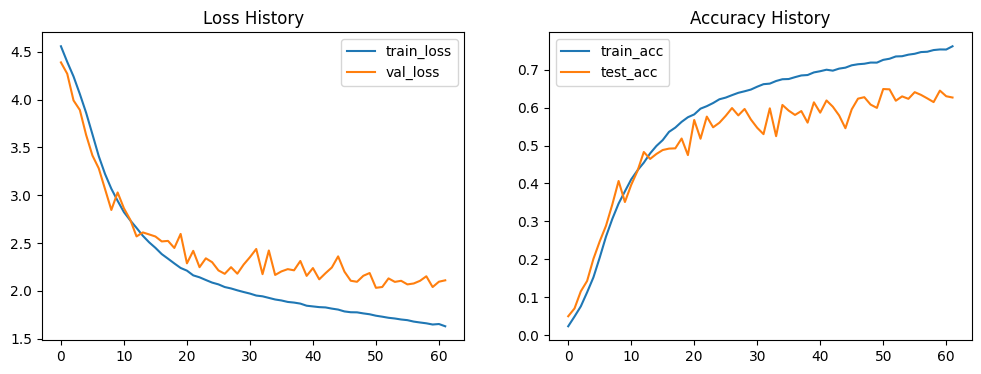

In [16]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label= 'train_loss')
plt.plot(val_losses, label = 'val_loss')
plt.title('Loss History')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label = 'train_acc')
plt.plot(val_accuracies, label = 'test_acc')
plt.title('Accuracy History')
plt.legend()

# 7. GradCAM

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 56.2 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


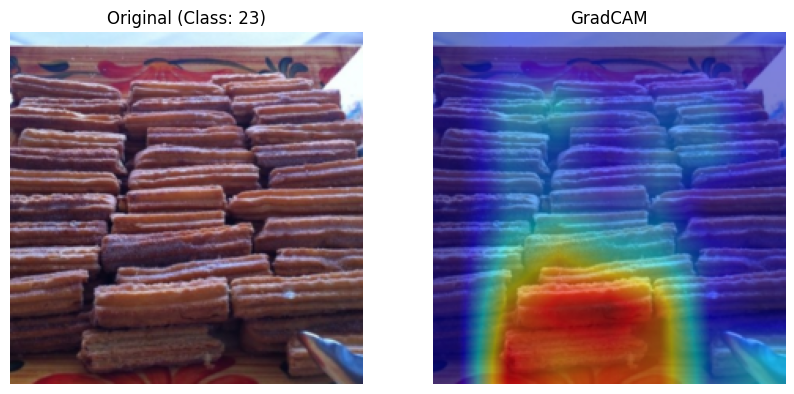

In [17]:
!pip install grad-cam -q

import numpy as np
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# Letzte Convolutional Layer von MobileNet als Target
target_layers = [model.layers[-1]]

# GradCAM Instanz erstellen
cam = GradCAM(model=model, target_layers=target_layers)

# Ein Bild aus dem Test-Loader holen
model.eval()
data_iter = iter(test_loader)
images, labels = next(data_iter)

# Nur das erste Bild des Batches verwenden
input_tensor = images[0:1].to(device)
label = labels[0].item()

# Forward pass für GradCAM
grayscale_cam = cam(input_tensor=input_tensor)
grayscale_cam = grayscale_cam[0, :]

# Originalbild für die Visualisierung ent-normalisieren
img = images[0].numpy().transpose(1, 2, 0)
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img = std * img + mean
img = np.clip(img, 0, 1)

# Heatmap über das Bild legen
visualization = show_cam_on_image(img, grayscale_cam, use_rgb=True)

# Visualisieren
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title(f"Original (Class: {label})")
plt.imshow(img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("GradCAM")
plt.imshow(visualization)
plt.axis('off')

plt.show()